In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 79.3 MB/s eta 0:00:00


In [3]:
import os
import shutil

PROJECT_DIR = "/content/drive/MyDrive/final-year-research"
WORK_DIR = "/content/final-year-research"

SRC_FOLDER = f"{PROJECT_DIR}/datasets/pixelated_dataset"
DEST_FOLDER = f"{WORK_DIR}/pixelated_dataset"

os.makedirs(WORK_DIR, exist_ok=True)
if os.path.exists(DEST_FOLDER):
    shutil.rmtree(DEST_FOLDER)   # delete existing folder

shutil.copytree(SRC_FOLDER, DEST_FOLDER)

print("Folder copied successfully")

Folder copied successfully


In [4]:
!ls /content/final-year-research/pixelated_dataset/

data.yaml  README.dataset.txt  README.roboflow.txt  train  valid


In [5]:
!find /content/final-year-research -maxdepth 3 -type d

/content/final-year-research
/content/final-year-research/pixelated_dataset
/content/final-year-research/pixelated_dataset/train
/content/final-year-research/pixelated_dataset/train/images
/content/final-year-research/pixelated_dataset/train/labels
/content/final-year-research/pixelated_dataset/valid
/content/final-year-research/pixelated_dataset/valid/images
/content/final-year-research/pixelated_dataset/valid/labels


In [6]:
import glob

ROOT = "/content/final-year-research/pixelated_dataset"

print("train images:", len(glob.glob(ROOT + "/train/images/*")))
print("train labels:", len(glob.glob(ROOT + "/train/labels/*")))
print("valid images:", len(glob.glob(ROOT + "/valid/images/*")))
print("valid labels:", len(glob.glob(ROOT + "/valid/labels/*")))

train images: 10098
train labels: 10098
valid images: 3284
valid labels: 3284


Selected Image: 009581_jpg.rf.18bba88a8347b35ab160f4f8f9e08a9c.jpg


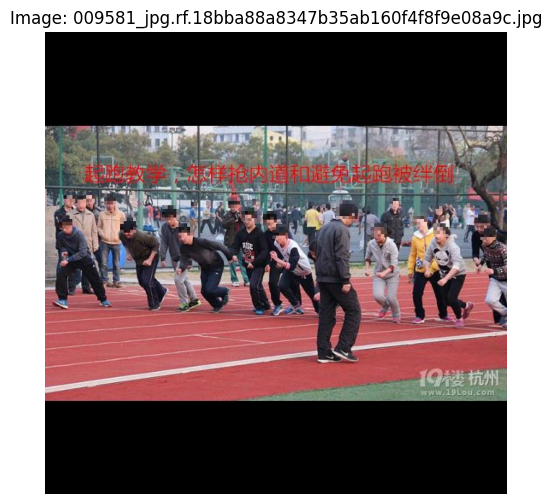

In [12]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import os
import random

# Folder containing images
image_dir = "/content/final-year-research/pixelated_dataset/valid/images"

# Get all image files
image_list = [f for f in os.listdir(image_dir) if f.endswith((".jpg", ".png", ".jpeg"))]

# Randomly select one image
random_image = random.choice(image_list)
image_path = os.path.join(image_dir, random_image)

print("Selected Image:", random_image)

# Read image
img = cv2.imread(image_path)

# Convert BGR to RGB
result_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Display
plt.figure(figsize=(8,6))
plt.imshow(result_img)
plt.axis("off")
plt.title(f"Image: {random_image}")
plt.show()

In [13]:
import yaml

yaml_path = "/content/final-year-research/WilderPerson_colab.yaml"

data = {
    "path": "/content/final-year-research/pixelated_dataset",
    "train": "/content/final-year-research/pixelated_dataset/train/images",
    "val": "/content/final-year-research/pixelated_dataset/valid/images",
    "names": {
        0: "pedestrian",
        1: "other"
    }
}

with open(yaml_path, "w") as f:
    yaml.dump(data, f, sort_keys=False)

print("YAML fixed! Now defining 2 classes (0 and 1).")

YAML fixed! Now defining 2 classes (0 and 1).


In [14]:
!yolo detect train \
  model=yolov8s.pt \
  data="/content/final-year-research/WilderPerson_colab.yaml" \
  epochs=50 \
  imgsz=640 \
  batch=16 \
  device=0 \
  patience=20 \
  project="/content/drive/MyDrive/final-year-research/runs" \
  name="wilderperson_pixelated_research_v1"

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/final-year-research/WilderPerson_colab.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=wilderperson_pixelated_research_v1, nbs=64, nms=False, opset=None, optimize=False